# Sign Language Detection
### ASL (American Sign Language) Alphabet Recognition

---

**Project Overview:**  
In this notebook, we will build a **Convolutional Neural Network (CNN)** that can recognize American Sign Language (ASL) hand signs from images.  
We'll go from raw image data all the way to **real-time webcam prediction** using OpenCV.

**Dataset:** [ASL Alphabet Dataset – Kaggle](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)  

**Dataset Structure:**
```
asl_alphabet_train/
    A/
        img1.jpg
        img2.jpg
    B/
        img1.jpg
    ...
    Z/
        img1.jpg
```

---

In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

import cv2

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("All libraries imported successfully!")

I0000 00:00:1775587959.850431  454187 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775587959.886226  454187 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775587960.885339  454187 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow Version: 2.21.0
GPU Available: []
All libraries imported successfully!


E0000 00:00:1775587965.134526  454187 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
DATASET_PATH   = "asl_alphabet_train"  # UPDATE THIS PATH
IMG_SIZE       = (64, 64)              # Resize all images to 64x64
BATCH_SIZE     = 32                    # Images processed per step
VALIDATION_SPLIT = 0.2                 # 20% for validation
SEED           = 42                    # For reproducibility

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_PATH}'.\n"
        "Please update DATASET_PATH to point to your dataset folder."
    )

CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"Dataset path: {os.path.abspath(DATASET_PATH)}")

total_images = sum(
    len(os.listdir(os.path.join(DATASET_PATH, cls)))
    for cls in CLASS_NAMES
)
print(f"Total images found: {total_images:,}")

Found 29 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Dataset path: /home/kanishk/Downloads/SignLanguageProject/Final_Model/asl_alphabet_train
Total images found: 87,000


IndexError: index 4 is out of bounds for axis 0 with size 4

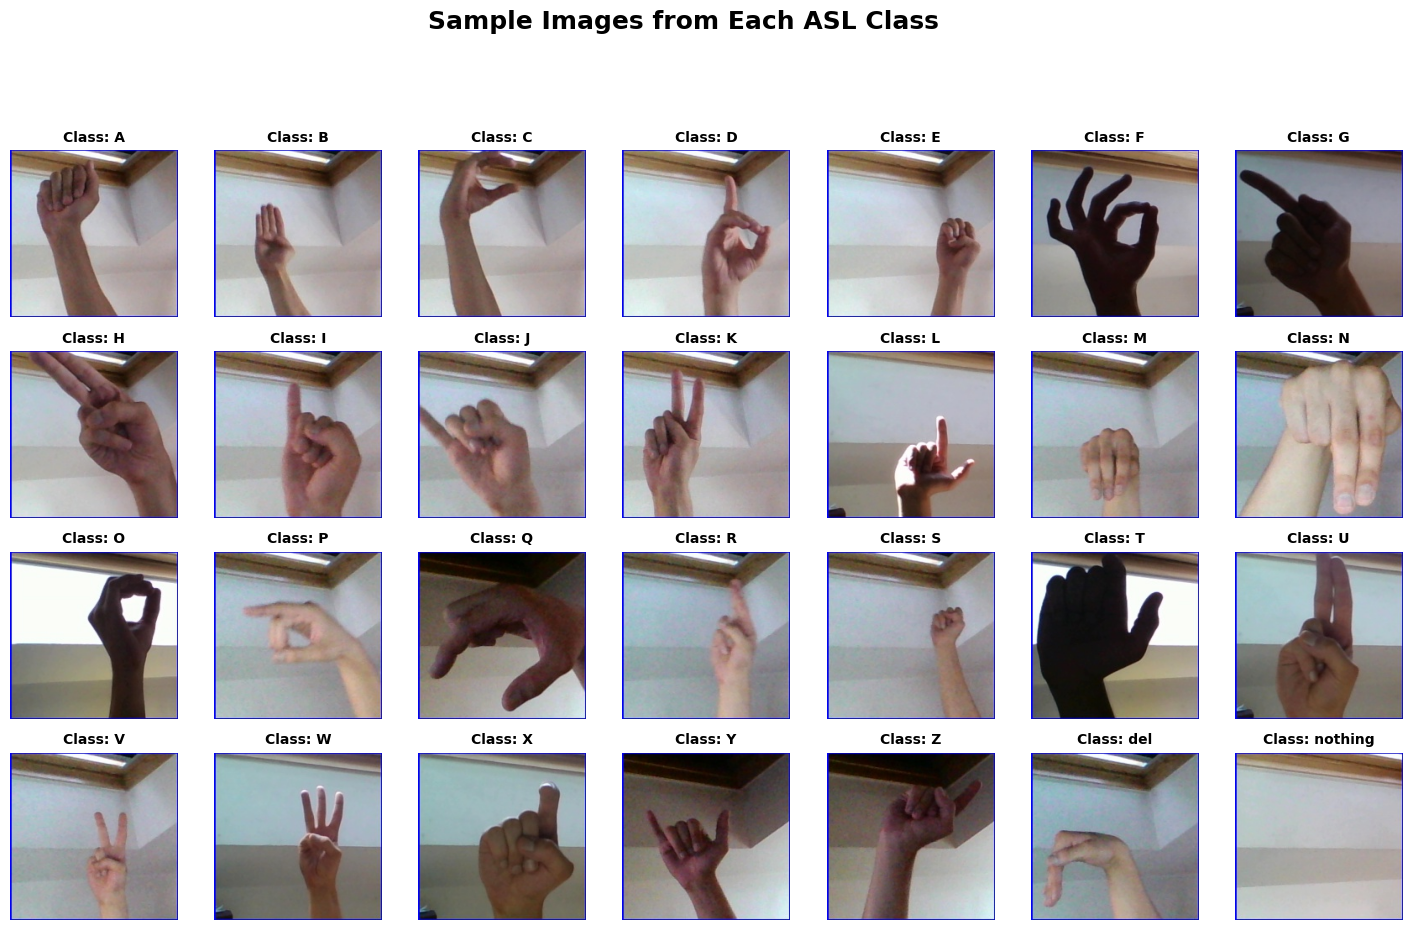

In [3]:
fig, axes = plt.subplots(4, 7, figsize=(18, 10))
fig.suptitle('Sample Images from Each ASL Class', fontsize=18, fontweight='bold', y=1.02)

for idx, cls in enumerate(CLASS_NAMES):
    class_folder = os.path.join(DATASET_PATH, cls)
    images = os.listdir(class_folder)
    
    if images:
        random_img = random.choice(images)
        img_path = os.path.join(class_folder, random_img)
        img = mpimg.imread(img_path)
        
        row, col = idx // 7, idx % 7
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'Class: {cls}', fontsize=10, fontweight='bold')
        axes[row, col].axis('off')

for i in range(NUM_CLASSES, 28):
    axes[i // 7, i % 7].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sample images displayed.")

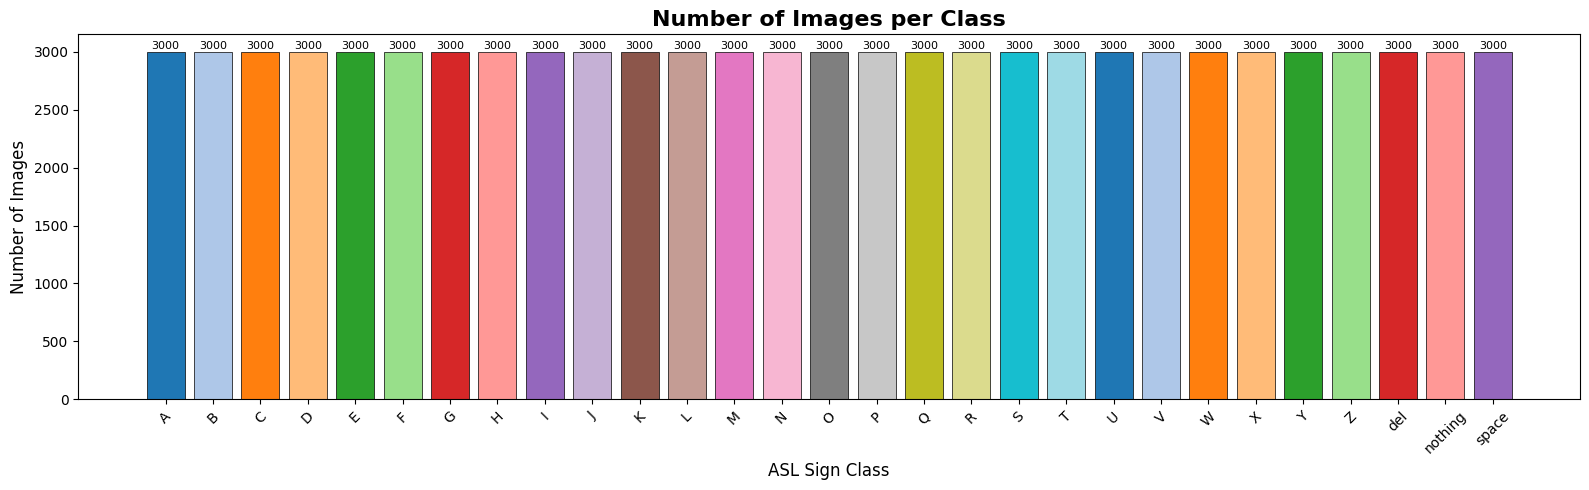

Min images in a class: 3,000
Max images in a class: 3,000


In [4]:
class_counts = {
    cls: len(os.listdir(os.path.join(DATASET_PATH, cls)))
    for cls in CLASS_NAMES
}

plt.figure(figsize=(16, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=plt.cm.tab20.colors[:NUM_CLASSES], edgecolor='black', linewidth=0.5)
plt.title('Number of Images per Class', fontsize=16, fontweight='bold')
plt.xlabel('ASL Sign Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)

for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Min images in a class: {min(class_counts.values()):,}")
print(f"Max images in a class: {max(class_counts.values()):,}")

In [5]:
preprocess_gen = ImageDataGenerator(
    rescale=1.0/255,          # Normalizing: divide every pixel by 255
    validation_split=0.2      # Reserving 20% for validation
)

val_data = preprocess_gen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # One-hot encoding
    subset='validation',       # Use the 20% validation split
    seed=SEED,
    shuffle=False              # Keep order for evaluation
)

print(f"\nPreprocessing configured.")
print(f"   Image size : {IMG_SIZE}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Classes    : {val_data.num_classes}")
print(f"   Val images : {val_data.samples:,}")
print(f"\nClass → Index mapping:")
print(val_data.class_indices)

Found 17400 images belonging to 29 classes.

Preprocessing configured.
   Image size : (64, 64)
   Batch size : 32
   Classes    : 29
   Val images : 17,400

Class → Index mapping:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}


Found 69600 images belonging to 29 classes.
Augmentation generator ready.
   Training images  : 69,600
   Validation images: 17,400


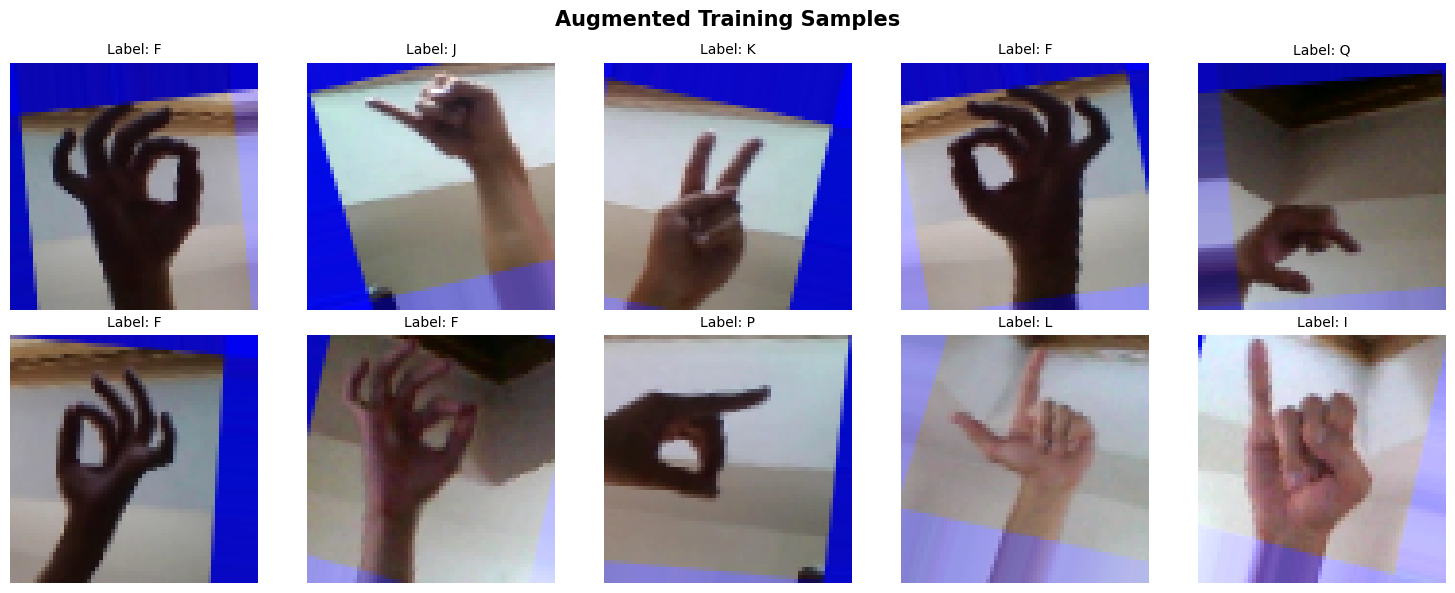

In [6]:
augment_gen = ImageDataGenerator(
    rescale=1.0/255,            # Normalizing pixel values
    rotation_range=15,          # Rotate images up to 15 degrees
    width_shift_range=0.15,     # Shift image left/right by 15%
    height_shift_range=0.15,    # Shift image up/down by 15%
    zoom_range=0.15,            # Zoom in/out by 15%
    horizontal_flip=True,       # Flip image horizontally
    brightness_range=[0.8, 1.2],# Randomly adjust brightness
    fill_mode='nearest',        # Fill empty pixels after transform
    validation_split=0.2        # Keep 20% aside for validation
)

train_data = augment_gen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # Output: one-hot encoded labels
    subset='training',          # Use the 80% training split
    seed=SEED,
    shuffle=True                # Shuffle training data each epoch
)

print(f"Augmentation generator ready.")
print(f"   Training images  : {train_data.samples:,}")
print(f"   Validation images: {val_data.samples:,}")

sample_batch_imgs, sample_batch_labels = next(train_data)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Augmented Training Samples', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch_imgs[i])
    label_idx = np.argmax(sample_batch_labels[i])
    ax.set_title(f'Label: {CLASS_NAMES[label_idx]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
total_samples = train_data.samples + val_data.samples
train_pct = (train_data.samples / total_samples) * 100
val_pct   = (val_data.samples   / total_samples) * 100

print("="*50)
print("         Dataset Split Summary")
print("="*50)
print(f"  Total Images     : {total_samples:>8,}")
print(f"  Training Images  : {train_data.samples:>8,}  ({train_pct:.1f}%)")
print(f"  Validation Images: {val_data.samples:>8,}  ({val_pct:.1f}%)")
print(f"  Number of Classes: {NUM_CLASSES:>8}")
print(f"  Image Size       : {IMG_SIZE[0]}x{IMG_SIZE[1]} pixels")
print(f"  Batch Size       : {BATCH_SIZE:>8}")
print("="*50)

STEPS_PER_EPOCH = train_data.samples // BATCH_SIZE
VALIDATION_STEPS = val_data.samples // BATCH_SIZE
print(f"  Steps/Epoch      : {STEPS_PER_EPOCH}")
print(f"  Validation Steps : {VALIDATION_STEPS}")
print("\nTrain-test split confirmed!")

         Dataset Split Summary
  Total Images     :   87,000
  Training Images  :   69,600  (80.0%)
  Validation Images:   17,400  (20.0%)
  Number of Classes:       29
  Image Size       : 64x64 pixels
  Batch Size       :       32
  Steps/Epoch      : 2175
  Validation Steps : 543

Train-test split confirmed!


In [8]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential(name="ASL_CNN")

    # Block 1: Extract low-level features (edges, colors)
    model.add(Conv2D(32, (3, 3), activation='relu',
                     padding='same', input_shape=input_shape))
    model.add(BatchNormalization())          # Normalize activations
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2))) # 64x64 → 32x32
    model.add(Dropout(0.25))                 # 25% neurons dropped

    # Block 2: Extract mid-level features (curves, patterns)
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2))) # 32x32 → 16x16
    model.add(Dropout(0.25))

    # Block 3: Extract high-level features (hand shapes)
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2))) # 16x16 → 8x8
    model.add(Dropout(0.4))

    # Classifier Head
    model.add(Flatten())                     # 8x8x128 → 8192 vector
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))                  # 50% dropout — strong regularization

    # Output Layer
    model.add(Dense(num_classes, activation='softmax'))  # One prob per class

    return model

INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3) 
model = build_cnn_model(INPUT_SHAPE, NUM_CLASSES)

model.summary()

print(f"\n Model built successfully!")
print(f"   Input shape : {INPUT_SHAPE}")
print(f"   Output units: {NUM_CLASSES} (one per class)")

Model: "ASL_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,394,685 (9.13 MB)

 Trainable params: 2,393,277 (9.13 MB)

 Non-trainable params: 1,408 (5.50 KB)


 Model built successfully!
   Input shape : (64, 64, 3)
   Output units: 29 (one per class)


In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',   # Multi-class classification loss
    metrics=['accuracy']
)

callbacks = [
    # Stop training if val_accuracy doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,  # Revert to best weights on stop
        verbose=1
    ),
    # Halve the learning rate if val_loss doesn't improve for 3 epochs
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath='best_asl_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(" Model compiled successfully!")
print("   Optimizer    : Adam (lr=0.001)")
print("   Loss         : categorical_crossentropy")
print("   Metric       : accuracy")
print("\n Callbacks configured:")
print("   • EarlyStopping    (patience=5, monitors val_accuracy)")
print("   • ReduceLROnPlateau(patience=3, monitors val_loss)")
print("   • ModelCheckpoint  (saves best_asl_model.h5)")

 Model compiled successfully!
   Optimizer    : Adam (lr=0.001)
   Loss         : categorical_crossentropy
   Metric       : accuracy

 Callbacks configured:
   • EarlyStopping    (patience=5, monitors val_accuracy)
   • ReduceLROnPlateau(patience=3, monitors val_loss)
   • ModelCheckpoint  (saves best_asl_model.h5)


In [10]:
EPOCHS = 20  # Max epochs

print(f" Starting training for up to {EPOCHS} epochs...")
print(f"   Training samples  : {train_data.samples:,}")
print(f"   Validation samples: {val_data.samples:,}")
print("-" * 50)

history = model.fit(
    train_data,                          
    steps_per_epoch=STEPS_PER_EPOCH,     # Batches per epoch
    epochs=EPOCHS,
    validation_data=val_data,            
    validation_steps=VALIDATION_STEPS,   # Batches for validation
    callbacks=callbacks,                 
    verbose=1
)

print("\n Training complete!")
print(f"   Epochs run       : {len(history.history['accuracy'])}")
print(f"   Final Train Acc  : {history.history['accuracy'][-1]:.4f}")
print(f"   Final Val Acc    : {history.history['val_accuracy'][-1]:.4f}")
print(f"   Best Val Acc     : {max(history.history['val_accuracy']):.4f}")

 Starting training for up to 20 epochs...
   Training samples  : 69,600
   Validation samples: 17,400
--------------------------------------------------
Epoch 1/20


I0000 00:00:1775587996.025575  454187 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.2507 - loss: 2.8294
Epoch 1: val_accuracy improved from None to 0.76560, saving model to best_asl_model.h5



Epoch 1: finished saving model to best_asl_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 556s 255ms/step - accuracy: 0.4464 - loss: 1.8895 - val_accuracy: 0.7656 - val_loss: 0.6838 - learning_rate: 0.0010
Epoch 2/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8019 - loss: 0.5800
Epoch 2: val_accuracy did not improve from 0.76560
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 546s 251ms/step - accuracy: 0.8361 - loss: 0.4804 - val_accuracy: 0.7604 - val_loss: 0.7724 - learning_rate: 0.0010
Epoch 3/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8909 - loss: 0.3227
Epoch 3: val_accuracy improved from 0.76560 to 0.84795, saving model to best_asl_model.h5



Epoch 3: finished saving model to best_asl_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 545s 250ms/step - accuracy: 0.9021 - loss: 0.2888 - val_accuracy: 0.8480 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 4/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9283 - loss: 0.2215
Epoch 4: val_accuracy improved from 0.84795 to 0.89244, saving model to best_asl_model.h5


...


Epoch 5: finished saving model to best_asl_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 535s 246ms/step - accuracy: 0.9449 - loss: 0.1653 - val_accuracy: 0.9045 - val_loss: 0.2982 - learning_rate: 0.0010
Epoch 6/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9524 - loss: 0.1476
Epoch 6: val_accuracy improved from 0.90452 to 0.90579, saving model to best_asl_model.h5



Epoch 6: finished saving model to best_asl_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 522s 240ms/step - accuracy: 0.9537 - loss: 0.1423 - val_accuracy: 0.9058 - val_loss: 0.3257 - learning_rate: 0.0010
Epoch 7/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9551 - loss: 0.1333
Epoch 7: val_accuracy improved from 0.90579 to 0.95079, saving model to best_asl_model.h5



Epoch 7: finished saving model to best_asl_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 535s 246ms/step - accuracy: 0.9564 - loss: 0.1314 - val_accuracy: 0.9508 - val_loss: 0.2470 - learning_rate: 0.0010
Epoch 8/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9653 - loss: 0.1033
Epoch 8: val_accuracy did not improve from 0.95079
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 541s 249ms/step - accuracy: 0.9653 - loss: 0.1063 - val_accuracy: 0.9061 - val_loss: 0.3298 - learning_rate: 0.0010
Epoch 9/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9660 - loss: 0.1036
Epoch 9: val_accuracy did not improve from 0.95079
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 528s 243ms/step - accuracy: 0.9670 - loss: 0.0998 - val_accuracy: 0.9343 - val_loss: 0.3435 - learning_rate: 0.0010
Epoch 10/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9689 - loss: 0.0936
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: val_accuracy did not improve from 0.95079
217


Epoch 12: finished saving model to best_asl_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 528s 243ms/step - accuracy: 0.9841 - loss: 0.0501 - val_accuracy: 0.9575 - val_loss: 0.2181 - learning_rate: 5.0000e-04
Epoch 13/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9851 - loss: 0.0476
Epoch 13: val_accuracy did not improve from 0.95747
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 518s 238ms/step - accuracy: 0.9856 - loss: 0.0464 - val_accuracy: 0.9286 - val_loss: 0.3932 - learning_rate: 5.0000e-04
Epoch 14/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9848 - loss: 0.0475
Epoch 14: val_accuracy improved from 0.95747 to 0.96564, saving model to best_asl_model.h5



Epoch 14: finished saving model to best_asl_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 519s 239ms/step - accuracy: 0.9854 - loss: 0.0451 - val_accuracy: 0.9656 - val_loss: 0.1363 - learning_rate: 5.0000e-04
Epoch 15/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9854 - loss: 0.0447
Epoch 15: val_accuracy did not improve from 0.96564
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 518s 238ms/step - accuracy: 0.9858 - loss: 0.0433 - val_accuracy: 0.9477 - val_loss: 0.3310 - learning_rate: 5.0000e-04
Epoch 16/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9873 - loss: 0.0371
Epoch 16: val_accuracy did not improve from 0.96564
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 518s 238ms/step - accuracy: 0.9872 - loss: 0.0393 - val_accuracy: 0.9511 - val_loss: 0.1993 - learning_rate: 5.0000e-04
Epoch 17/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9879 - loss: 0.0384
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: val_accuracy did not improve

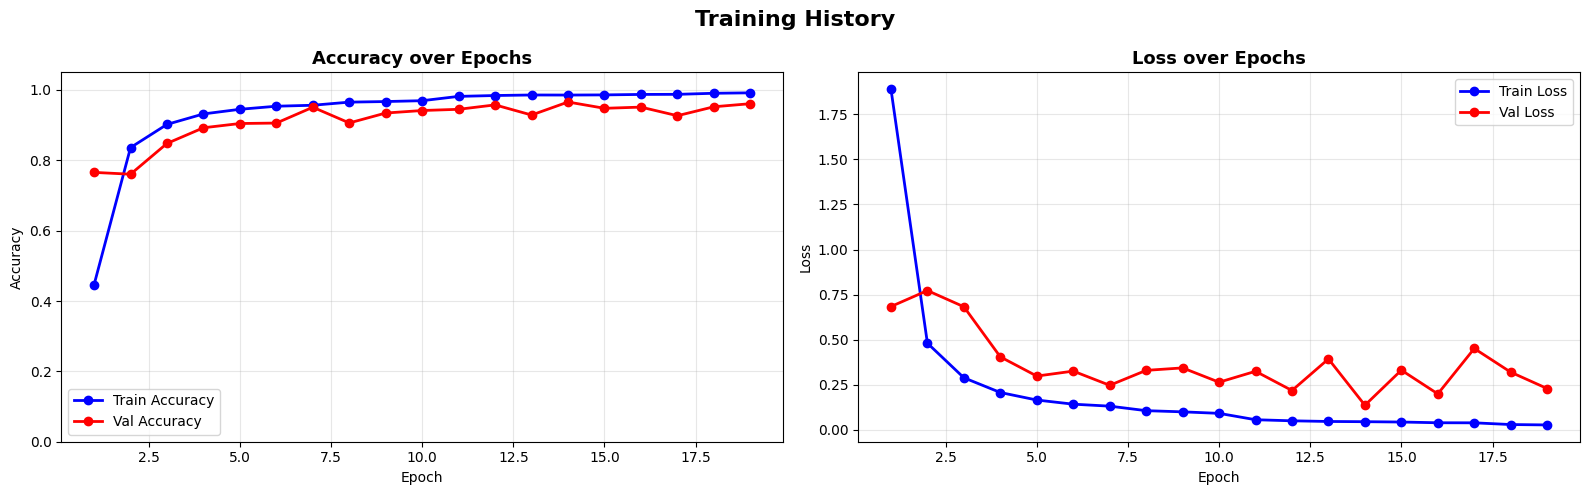

 Training plots saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, history.history['accuracy'],     'b-o', label='Train Accuracy', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Accuracy',   linewidth=2)
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

axes[1].plot(epochs_ran, history.history['loss'],     'b-o', label='Train Loss', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss',   linewidth=2)
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Training plots saved.")

In [12]:
print(" Evaluating model on validation set...")
val_data.reset()  # Reset generator to start from beginning

val_loss, val_accuracy = model.evaluate(val_data, verbose=1)
print(f"\n{'='*40}")
print(f"  Validation Loss    : {val_loss:.4f}")
print(f"  Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"{'='*40}")

# Predict all validation samples
print("\n Generating predictions for classification report...")
val_data.reset()
y_pred_probs = model.predict(val_data, steps=VALIDATION_STEPS + 1, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)  # Predicted class indices
y_true       = val_data.classes[:len(y_pred)]   # True class indices

print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

 Evaluating model on validation set...
544/544 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.9657 - loss: 0.1361

  Validation Loss    : 0.1361
  Validation Accuracy: 96.57%

 Generating predictions for classification report...
544/544 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step

 Classification Report:
              precision    recall  f1-score   support

           A       0.96      1.00      0.98       600
           B       0.99      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       600
           E       0.94      1.00      0.97       600
           F       1.00      1.00      1.00       600
           G       0.87      0.96      0.91       600
           H       0.88      1.00      0.94       600
           I       0.98      0.85      0.91       600
           J       1.00      0.82      0.90       600
           K       1.00      1.00      1.00       600
           L       1.00      1.00      1.00       60

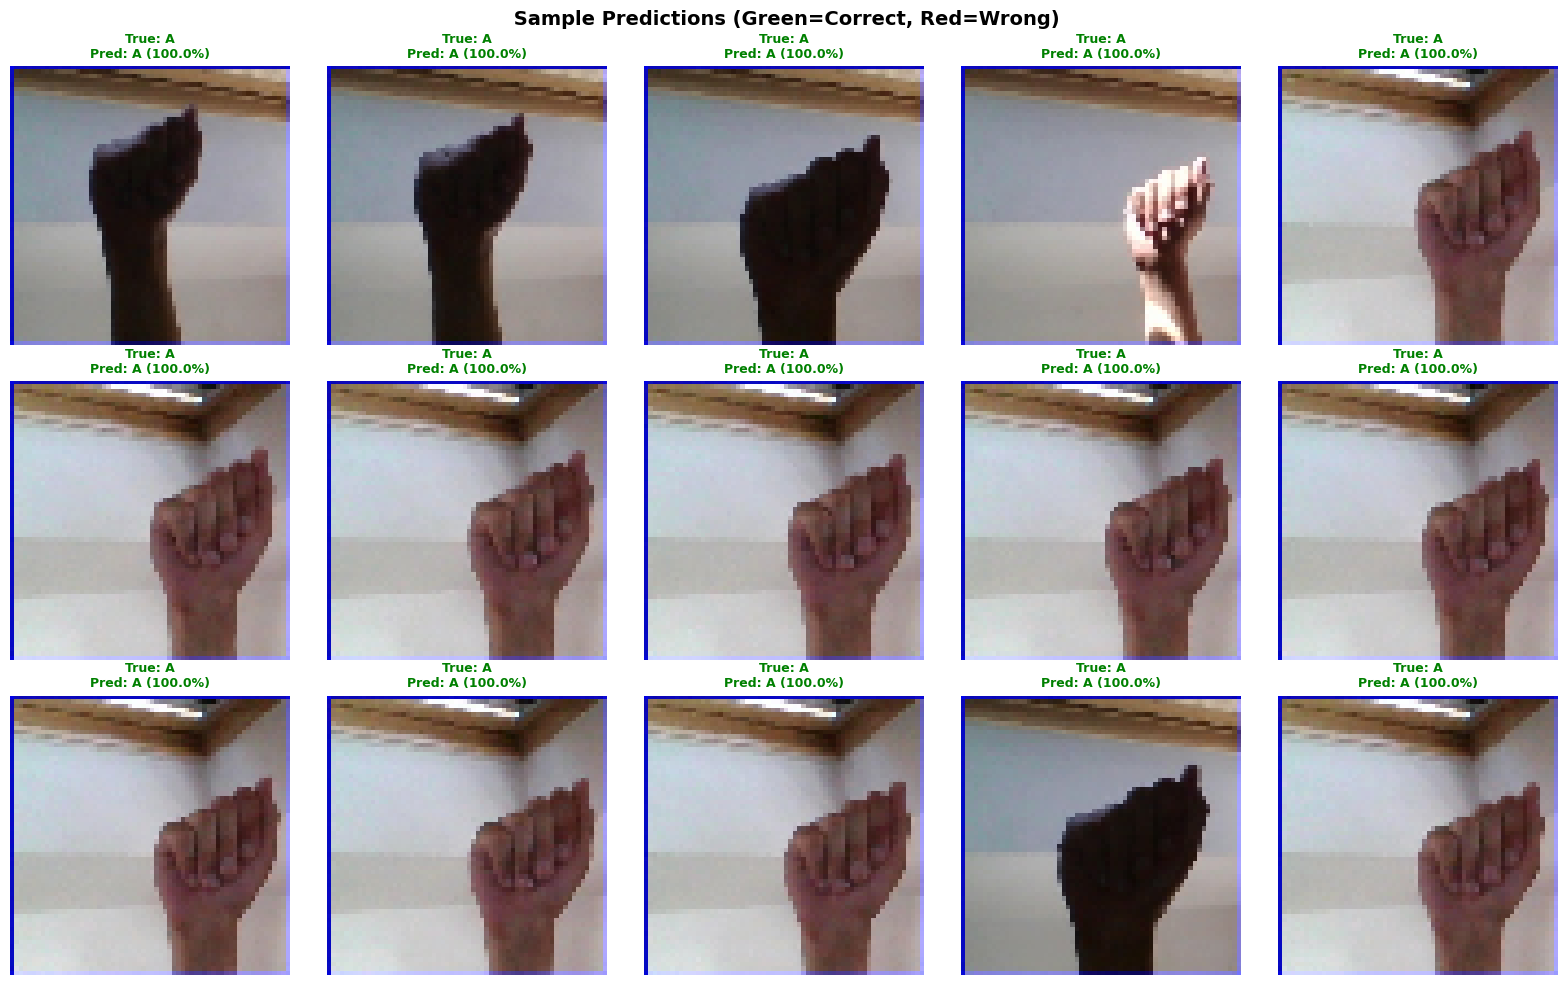

In [13]:
val_data.reset()
sample_imgs, sample_labels = next(val_data)

preds = model.predict(sample_imgs, verbose=0)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(sample_labels, axis=1)

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle(' Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs):
        ax.axis('off')
        continue
    
    ax.imshow(sample_imgs[i])
    
    true_label = CLASS_NAMES[true_classes[i]]
    pred_label = CLASS_NAMES[pred_classes[i]]
    confidence = preds[i][pred_classes[i]] * 100
    
    color = 'green' if true_classes[i] == pred_classes[i] else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

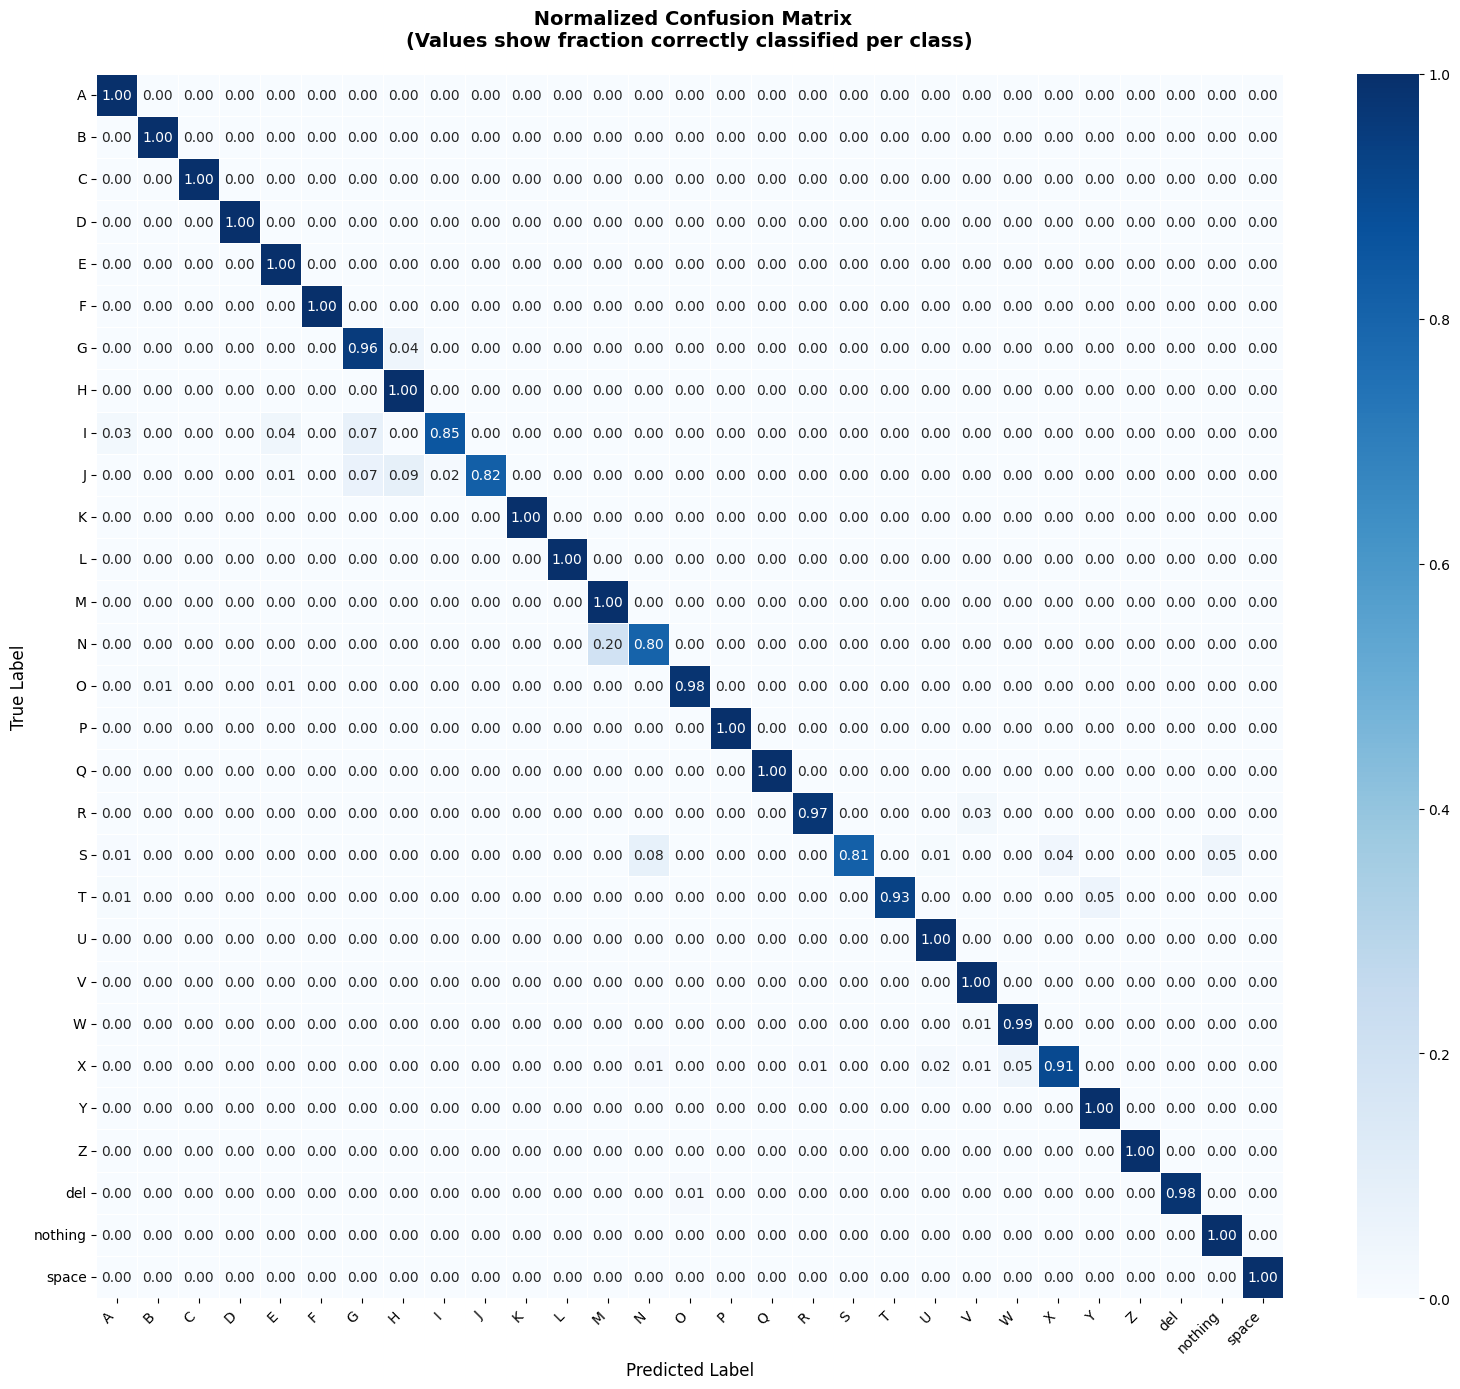


 Top 5 Most Confused Class Pairs:
   'N' predicted as 'M': 117 times
   'J' predicted as 'H': 52 times
   'S' predicted as 'N': 49 times
   'I' predicted as 'G': 45 times
   'J' predicted as 'G': 40 times


In [14]:
cm = confusion_matrix(y_true, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title(' Normalized Confusion Matrix\n(Values show fraction correctly classified per class)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n Top 5 Most Confused Class Pairs:")
np.fill_diagonal(cm, 0)
confused_pairs = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))

confused_pairs.sort(reverse=True)
for count, true_c, pred_c in confused_pairs[:5]:
    print(f"   '{true_c}' predicted as '{pred_c}': {int(count)} times")

In [19]:
import json
MODEL_SAVE_PATH = "best_asl_model.h5"
model.save("asl_model.keras")

with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

model.export("asl_saved_model")

# Test Loading the Model
print("\n Testing model reload...")
loaded_model = load_model(MODEL_SAVE_PATH)
test_loss, test_acc = loaded_model.evaluate(val_data, verbose=0)
print(f" Loaded model validation accuracy: {test_acc*100:.2f}%")
print(" Model loads and works correctly!")

# File sizes
model_size_mb = os.path.getsize(MODEL_SAVE_PATH) / (1024 * 1024)
print(f"\n Model file size: {model_size_mb:.1f} MB")

INFO:tensorflow:Assets written to: asl_saved_model/assets


INFO:tensorflow:Assets written to: asl_saved_model/assets


Saved artifact at 'asl_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 29), dtype=tf.float32, name=None)
Captures:
  123560088260048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088259856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088259280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088260816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088257360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088258512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088257552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088260432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088262928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088263312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123560088262160:


 Testing model reload...
 Loaded model validation accuracy: 96.57%
 Model loads and works correctly!

 Model file size: 27.5 MB
